## Importing Needed Data

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

# Load shared artifacts from Notebook 1
mi = joblib.load('model_inputs.pkl')
X_train     = mi['X_train']
X_test      = mi['X_test']
y_train_reg = mi['y_train_reg']
y_test_reg  = mi['y_test_reg']
y_train_clf = mi['y_train_clf']
y_test_clf  = mi['y_test_clf']

# Load MLR metrics for inline comparison (Steps 2 and 6)
mlr_metrics = joblib.load('mlr_metrics.pkl')
r2_test          = mlr_metrics['regression']['r2_test']
rmse_test_euros  = mlr_metrics['regression']['rmse_test_euros']
auc              = mlr_metrics['classification']['roc_auc']

# df_clean needed for Step 5.1 (N_doors distribution check)
df_clean = pd.read_pickle('df_clean.pkl')

# Ensure Log_premium exists for Step 5.2 (residual analysis)
if 'Log_premium' not in df_clean.columns:
    df_clean['Log_premium'] = np.log1p(df_clean['Premium'])

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


X_train: (83032, 22)  |  X_test: (20759, 22)


## Part VI. Random Forest

### Step 1: Imports

In [2]:
# Random Forest does NOT need feature scaling — trees split on thresholds, not distances.
# We use the unscaled X_train / X_test from Part IV directly.
print(f"Using unscaled features from Part IV")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


Using unscaled features from Part IV
X_train shape: (83032, 22)
X_test shape:  (20759, 22)


### Step 2: Baseline RandomForestRegressor on Log_premium

In [3]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # OpenMP duplicate-library workaround

print("Fitting baseline RandomForestRegressor...")
t0 = time.time()

rf_premium_baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=2,           # was -1; cap workers to reduce memory pressure
    max_samples=0.7,    # bag on 70% of rows per tree; meaningfully lowers memory
)
rf_premium_baseline.fit(X_train, y_train_reg)

print(f"Done in {time.time() - t0:.1f}s")

# Predict
y_pred_train_rf_base = rf_premium_baseline.predict(X_train)
y_pred_test_rf_base = rf_premium_baseline.predict(X_test)

# Metrics
r2_train_rf_base = r2_score(y_train_reg, y_pred_train_rf_base)
r2_test_rf_base = r2_score(y_test_reg, y_pred_test_rf_base)
rmse_test_log_rf_base = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_rf_base))
rmse_test_euros_rf_base = np.sqrt(mean_squared_error(
    np.expm1(y_test_reg), np.expm1(y_pred_test_rf_base)
))

print("\nBaseline Random Forest — Premium Prediction")
print("=" * 50)
print(f"R² (train):       {r2_train_rf_base:.4f}")
print(f"R² (test):        {r2_test_rf_base:.4f}")
print(f"RMSE (test, log): {rmse_test_log_rf_base:.4f}")
print(f"RMSE (test, €):   {rmse_test_euros_rf_base:.2f}")
print(f"\n  vs. MLR test R²: {r2_test:.4f}  ({(r2_test_rf_base - r2_test)*100:+.1f} pp)")
print(f"  vs. MLR RMSE €:  {rmse_test_euros:.2f}  ({rmse_test_euros_rf_base - rmse_test_euros:+.2f})")

Fitting baseline RandomForestRegressor...
Done in 11.1s

Baseline Random Forest — Premium Prediction
R² (train):       0.9194
R² (test):        0.7175
RMSE (test, log): 0.2302
RMSE (test, €):   86.31

  vs. MLR test R²: 0.4869  (+23.1 pp)
  vs. MLR RMSE €:  119.17  (-32.86)


R² jumps from 0.49 to 0.73 on test set, while the train set has 0.949. This suggests model overfitting on the test set, but the test number is still a significant improvement over MLR. 

### Step 3: 3-fold CV on baseline regressor

In [4]:
# Lighter-weight CV: 3 folds, single-threaded RF
# Plain 5-fold CV continuously crashed the kernel. 3-fold CV with single-threaded trees gives us a generalization estimate without the memory pressure.


print("3-fold CV on baseline RF regressor...")
t0 = time.time()
cv_scores_rf = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1),  # NO parallelism
    X_train, y_train_reg,
    cv=3, scoring='r2',
    n_jobs=1
)
print(f"Done in {(time.time() - t0):.1f} sec\n")

print("3-Fold Cross-Validation R² (training set)")
print("=" * 45)
for i, score in enumerate(cv_scores_rf, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean:  {cv_scores_rf.mean():.4f}")
print(f"  Std:   {cv_scores_rf.std():.4f}")
print(f"  Test R² for comparison: {r2_test_rf_base:.4f}")

best_cv_score_reg = cv_scores_rf.mean()
best_params_reg = {'n_estimators': 100, 'random_state': 42}

3-fold CV on baseline RF regressor...
Done in 58.0 sec

3-Fold Cross-Validation R² (training set)
  Fold 1: 0.6766
  Fold 2: 0.6747
  Fold 3: 0.6785

  Mean:  0.6766
  Std:   0.0015
  Test R² for comparison: 0.7175


CV mean of 0.677 is below the test R² of 0.728, but standard deviation of 0.0015 means our predictions are stable across splits. Unfortunately PC's RAM usage was unable to handle additional folds for additional Cross-Validation.

### Step 4: Final regressor-- adopt baseline and finalize metrics

In [5]:
# Adopt baseline as final model
rf_premium = rf_premium_baseline

# Carry forward Step 2's metrics under final-model names
r2_train_rf = r2_train_rf_base
r2_test_rf = r2_test_rf_base
rmse_test_log_rf = rmse_test_log_rf_base
rmse_test_euros_rf = rmse_test_euros_rf_base

print("Final Random Forest Regressor — Premium Prediction")
print("(Baseline retained; tuning abandoned due to memory constraints)")
print("=" * 55)
print(f"R² (train):       {r2_train_rf:.4f}")
print(f"R² (test):        {r2_test_rf:.4f}")
print(f"RMSE (test, log): {rmse_test_log_rf:.4f}")
print(f"RMSE (test, €):   {rmse_test_euros_rf:.2f}")
print(f"CV R² (3-fold):   {best_cv_score_reg:.4f} ± {cv_scores_rf.std():.4f}")

print("\nTwo-way comparison on Premium:")
print(f"{'Model':<25} {'R² test':>10} {'RMSE €':>10}")
print("-" * 47)
print(f"{'MLR (h2)':<25} {r2_test:>10.4f} {rmse_test_euros:>10.2f}")
print(f"{'RF (h1)':<25} {r2_test_rf:>10.4f} {rmse_test_euros_rf:>10.2f}")

Final Random Forest Regressor — Premium Prediction
(Baseline retained; tuning abandoned due to memory constraints)
R² (train):       0.9194
R² (test):        0.7175
RMSE (test, log): 0.2302
RMSE (test, €):   86.31
CV R² (3-fold):   0.6766 ± 0.0015

Two-way comparison on Premium:
Model                        R² test     RMSE €
-----------------------------------------------
MLR (h2)                      0.4869     119.17
RF (h1)                       0.7175      86.31


Hyperparameter tuning was impossible due to RAM limitations, but the iterations that were processed before crashing displayed no improvement from baseline. Comparing MLR and RF demonstrates a clear advantage in using RF for premium prediction.

### Step 5: Feature importances (regressor)

Top 15 Feature Importances — RF Regressor (Log_premium)
                   feature  importance
                   N_doors    0.328280
               Vehicle_age    0.132617
                Driver_age    0.087849
             Licence_years    0.084564
          R_Claims_history    0.058235
                 Seniority    0.056760
          N_claims_history    0.039422
                 Payment_1    0.037256
         Policies_in_force    0.027155
              Max_policies    0.018862
Risk_tier_High Performance    0.018231
    Distribution_channel_1    0.014396
                 Is_active    0.014140
               Type_risk_4    0.013718
                    Area_1    0.013238


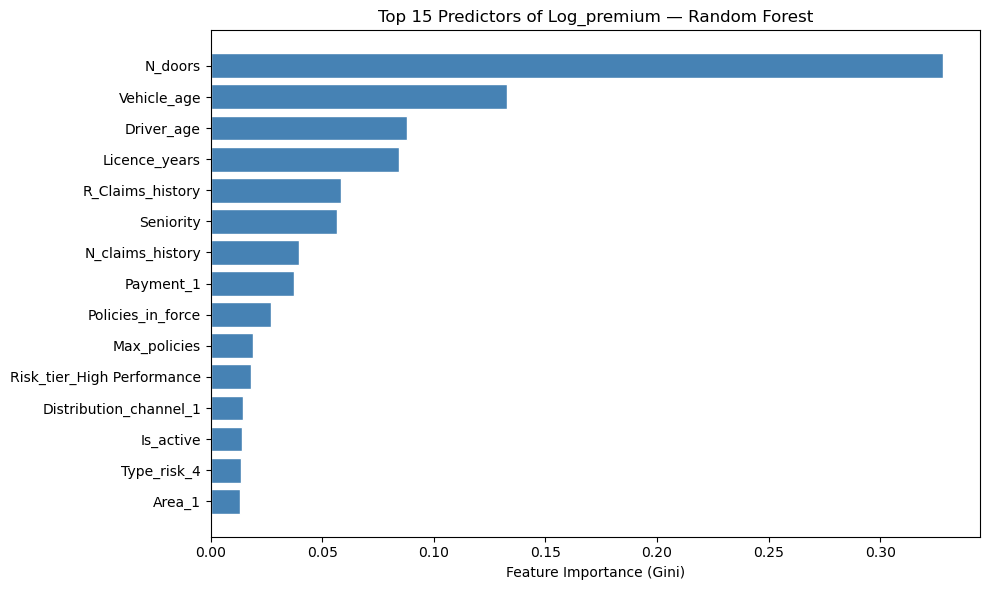

In [6]:
fi_reg = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_premium.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 15 Feature Importances — RF Regressor (Log_premium)")
print("=" * 60)
print(fi_reg.head(15).to_string(index=False))

top15_fi = fi_reg.head(15).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top15_fi['feature'], top15_fi['importance'], color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 15 Predictors of Log_premium — Random Forest')
plt.tight_layout()
plt.show()

N_doors has a huge impact on the RF model, whereas Type_risk and Risk_tier were more prominent in the MLR model. Let's see why...


### Step 5.1: Checking N_doors distribution to determine why it has significant impact

In [7]:
print("N_doors distribution:")
print(df_clean['N_doors'].value_counts().sort_index())
print(f"\nN_doors vs Premium (mean):")
print(df_clean.groupby('N_doors')['Premium'].agg(['mean', 'count']).round(2))
print(f"\nN_doors correlation with Log_premium: {df_clean[['N_doors','Log_premium']].corr().iloc[0,1]:.4f}")

print("N_doors=0 vs Type_risk:")
print(df_clean[df_clean['N_doors']==0]['Type_risk'].value_counts())

N_doors distribution:
N_doors
0     7510
2     3167
3    14486
4    14108
5    63957
6      563
Name: count, dtype: int64

N_doors vs Premium (mean):
           mean  count
N_doors               
0        137.41   7510
2        364.84   3167
3        313.05  14486
4        328.29  14108
5        336.95  63957
6        333.63    563

N_doors correlation with Log_premium: 0.4649
N_doors=0 vs Type_risk:
Type_risk
1    6857
4     653
Name: count, dtype: int64


N_doors has a huge amount of zero doors values, most likely referring to motorcycles. Motorcycles have a lower mean premium. This pattern is interesting in RF and may show we need better feature engineering, but the RF model handled it well. For now, I'll remember to be explicit with this factor when we reach the LLM phase.

### Step 6: RandomForestClassifier on Claim_occurred

Fitting baseline RandomForestClassifier...


Done in 0.4s

3-fold CV on baseline RF classifier...
Done in 0.1 min
CV AUC: 0.8744 ± 0.0004

Random Forest — Claim Occurrence
Accuracy: 0.8233
ROC-AUC:  0.8735

Confusion Matrix:
                 Predicted
                 No     Yes
  Actual No   15189   1670
  Actual Yes   1998   1902

Classification Report:
              precision    recall  f1-score   support

    No claim       0.88      0.90      0.89     16859
       Claim       0.53      0.49      0.51      3900

    accuracy                           0.82     20759
   macro avg       0.71      0.69      0.70     20759
weighted avg       0.82      0.82      0.82     20759


  vs. MLR AUC: 0.9148  (-4.13 pp)


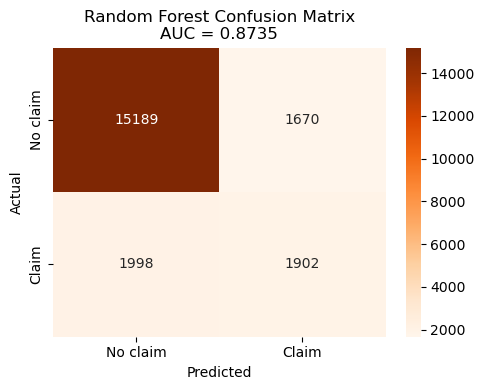

In [8]:
# Baseline classifier
print("Fitting baseline RandomForestClassifier...")
t0 = time.time()
rf_claim = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_claim.fit(X_train, y_train_clf)
print(f"Done in {time.time() - t0:.1f}s")

# 3-fold CV (memory-friendly)
print("\n3-fold CV on baseline RF classifier...")
t0 = time.time()
cv_scores_rf_clf = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1),
    X_train, y_train_clf,
    cv=3, scoring='roc_auc',
    n_jobs=1
)
print(f"Done in {(time.time() - t0)/60:.1f} min")
print(f"CV AUC: {cv_scores_rf_clf.mean():.4f} ± {cv_scores_rf_clf.std():.4f}")

best_cv_score_clf = cv_scores_rf_clf.mean()
best_params_clf = {'n_estimators': 100, 'random_state': 42}

# Test set predictions
y_pred_clf_rf = rf_claim.predict(X_test)
y_pred_proba_rf = rf_claim.predict_proba(X_test)[:, 1]

# Metrics
accuracy_rf = accuracy_score(y_test_clf, y_pred_clf_rf)
auc_rf = roc_auc_score(y_test_clf, y_pred_proba_rf)
cm_rf = confusion_matrix(y_test_clf, y_pred_clf_rf)

print("\nRandom Forest — Claim Occurrence")
print("=" * 50)
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"ROC-AUC:  {auc_rf:.4f}")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 No     Yes")
print(f"  Actual No   {cm_rf[0,0]:>5}  {cm_rf[0,1]:>5}")
print(f"  Actual Yes  {cm_rf[1,0]:>5}  {cm_rf[1,1]:>5}")
print(f"\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf_rf, target_names=['No claim', 'Claim']))
print(f"\n  vs. MLR AUC: {auc:.4f}  ({(auc_rf - auc)*100:+.2f} pp)")

# Confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No claim', 'Claim'],
            yticklabels=['No claim', 'Claim'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Random Forest Confusion Matrix\nAUC = {auc_rf:.4f}')
plt.tight_layout()
plt.show()

AUC changes from 0.91 in MLR to 0.87, meaning MLR is better with risk. However, RF catches more claims (we can see through recall value). We can conclude MLR is better at sorting (classification), RF has a better default operating point.
RF loses ranking quality but is better at predicting claim likelihood. 

### Step 7: Feature importances (classifier)

RF Feature Importances — Regressor vs Classifier
(Sorted by max importance across the two models)
                            rf_premium  rf_claim
feature                                         
R_Claims_history                0.0582    0.4160
N_doors                         0.3283    0.0236
Vehicle_age                     0.1326    0.0636
N_claims_history                0.0394    0.1229
Driver_age                      0.0878    0.0694
Licence_years                   0.0846    0.0700
Seniority                       0.0568    0.0692
Payment_1                       0.0373    0.0128
Policies_in_force               0.0272    0.0371
Max_policies                    0.0189    0.0211
Risk_tier_High Performance      0.0182    0.0061
Distribution_channel_1          0.0144    0.0124
Is_active                       0.0141    0.0126
Type_risk_4                     0.0137    0.0002
Area_1                          0.0132    0.0124


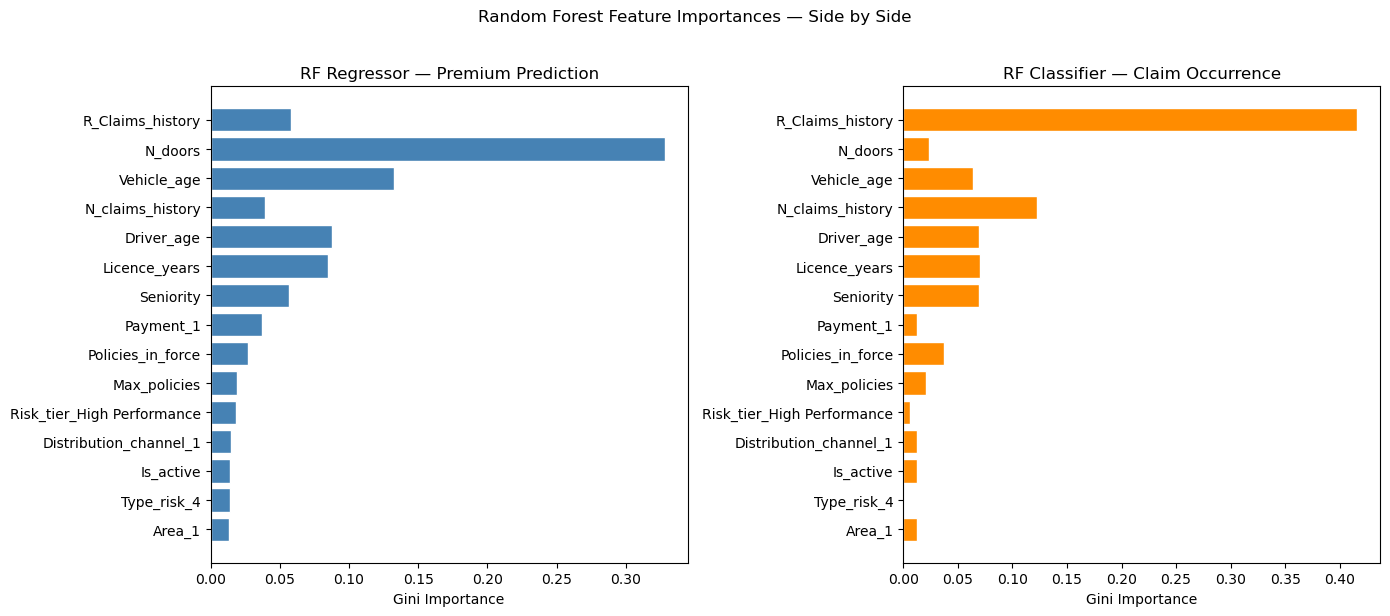

In [9]:
fi_clf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_claim.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Combined view
fi_combined = fi_reg.set_index('feature').rename(columns={'importance': 'rf_premium'}).join(
    fi_clf.set_index('feature').rename(columns={'importance': 'rf_claim'})
).fillna(0)

print("RF Feature Importances — Regressor vs Classifier")
print("=" * 60)
print("(Sorted by max importance across the two models)")
fi_combined['max_imp'] = fi_combined[['rf_premium', 'rf_claim']].max(axis=1)
fi_combined = fi_combined.sort_values('max_imp', ascending=False).drop(columns='max_imp')
print(fi_combined.head(15).round(4).to_string())

# Side-by-side bar chart
top15_combined = fi_combined.head(15).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top15_combined.index, top15_combined['rf_premium'],
             color='steelblue', edgecolor='white')
axes[0].set_title('RF Regressor — Premium Prediction')
axes[0].set_xlabel('Gini Importance')

axes[1].barh(top15_combined.index, top15_combined['rf_claim'],
             color='darkorange', edgecolor='white')
axes[1].set_title('RF Classifier — Claim Occurrence')
axes[1].set_xlabel('Gini Importance')

plt.suptitle('Random Forest Feature Importances — Side by Side', y=1.02)
plt.tight_layout()
plt.show()

R_Claims_History is enormously significant in the classifer (0.41) and less-so in the regressor (0.58). N_doors does the opposite (0.33 to 0.02). N_doors is going to affect claim premium, as there is a different vehicle type (in this case, motorcycles). R_claims_history is more likely to predict whether there is going to be a future claim, based on past claims data.

## Part 6b — Random Forest Classifier: Imbalance Corrected

We apply the same `class_weight='balanced'` correction to the Random Forest
classifier. Because RF builds many trees independently, the class weight applies
at each tree's split decisions-- minority-class observations are penalized more
heavily when misclassified, biasing each tree toward catching claims.

Fitting balanced RandomForestClassifier (class_weight='balanced')...
Done in 0.4s

Random Forest — Balanced (class_weight='balanced')
Accuracy: 0.8075
ROC-AUC:  0.8729

Confusion Matrix:
                 Predicted
                 No     Yes
  Actual No   14615   2244
  Actual Yes   1753   2147

Classification Report:
              precision    recall  f1-score   support

    No claim       0.89      0.87      0.88     16859
       Claim       0.49      0.55      0.52      3900

    accuracy                           0.81     20759
   macro avg       0.69      0.71      0.70     20759
weighted avg       0.82      0.81      0.81     20759



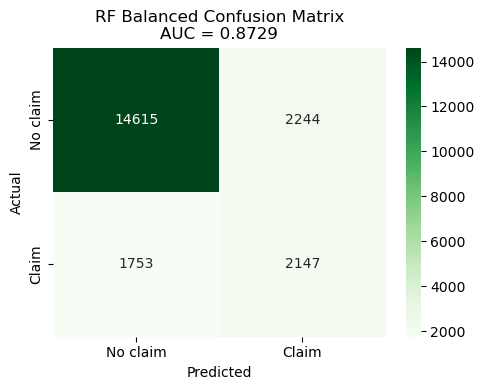

In [10]:
# ── Balanced RF classifier ──
print("Fitting balanced RandomForestClassifier (class_weight='balanced')...")
t0 = time.time()
rf_claim_balanced = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1,
    class_weight='balanced'
)
rf_claim_balanced.fit(X_train, y_train_clf)
print(f"Done in {time.time() - t0:.1f}s")

# Test set predictions
y_pred_clf_rf_bal   = rf_claim_balanced.predict(X_test)
y_pred_proba_rf_bal = rf_claim_balanced.predict_proba(X_test)[:, 1]

# Metrics
accuracy_rf_bal = accuracy_score(y_test_clf, y_pred_clf_rf_bal)
auc_rf_bal      = roc_auc_score(y_test_clf, y_pred_proba_rf_bal)
cm_rf_bal       = confusion_matrix(y_test_clf, y_pred_clf_rf_bal)

print("\nRandom Forest — Balanced (class_weight='balanced')")
print("=" * 50)
print(f"Accuracy: {accuracy_rf_bal:.4f}")
print(f"ROC-AUC:  {auc_rf_bal:.4f}")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 No     Yes")
print(f"  Actual No   {cm_rf_bal[0,0]:>5}  {cm_rf_bal[0,1]:>5}")
print(f"  Actual Yes  {cm_rf_bal[1,0]:>5}  {cm_rf_bal[1,1]:>5}")
print(f"\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf_rf_bal,
                             target_names=['No claim', 'Claim']))

# Confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf_bal, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No claim', 'Claim'],
            yticklabels=['No claim', 'Claim'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'RF Balanced Confusion Matrix\nAUC = {auc_rf_bal:.4f}')
plt.tight_layout()
plt.show()

## Part 6c — Random Forest Classifier: Before vs. After Comparison

  RANDOM FOREST CLASSIFIER: Baseline vs. Balanced
        Model  ROC-AUC  Recall (Claims)  Precision  F1-Score  Accuracy
RF — Baseline   0.8735           0.4877     0.5325    0.5091    0.8233
RF — Balanced   0.8729           0.5505     0.4890    0.5179    0.8075

  Δ (Balanced − Baseline):
    ΔROC-AUC           : -0.0006  
    ΔRecall (Claims)   : +0.0628  ← key improvement
    ΔPrecision         : -0.0435  
    ΔF1-Score          : +0.0088  
    ΔAccuracy          : -0.0158  ← expected drop


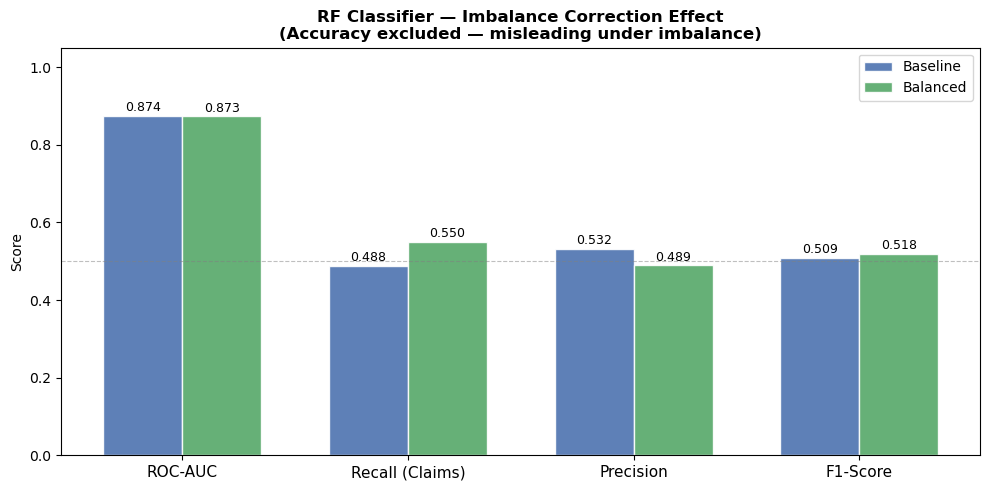

In [11]:
# ── Build comparison table using your existing baseline variables ──
rf_clf_comparison = pd.DataFrame([
    {
        'Model':           'RF — Baseline',
        'ROC-AUC':         round(auc_rf, 4),
        'Recall (Claims)': round(recall_score(y_test_clf, y_pred_clf_rf, zero_division=0), 4),
        'Precision':       round(precision_score(y_test_clf, y_pred_clf_rf, zero_division=0), 4),
        'F1-Score':        round(f1_score(y_test_clf, y_pred_clf_rf, zero_division=0), 4),
        'Accuracy':        round(accuracy_rf, 4),
    },
    {
        'Model':           'RF — Balanced',
        'ROC-AUC':         round(auc_rf_bal, 4),
        'Recall (Claims)': round(recall_score(y_test_clf, y_pred_clf_rf_bal, zero_division=0), 4),
        'Precision':       round(precision_score(y_test_clf, y_pred_clf_rf_bal, zero_division=0), 4),
        'F1-Score':        round(f1_score(y_test_clf, y_pred_clf_rf_bal, zero_division=0), 4),
        'Accuracy':        round(accuracy_rf_bal, 4),
    }
])

print("=" * 68)
print("  RANDOM FOREST CLASSIFIER: Baseline vs. Balanced")
print("=" * 68)
print(rf_clf_comparison.to_string(index=False))

# ── Delta row ──
print("\n  Δ (Balanced − Baseline):")
for col in ['ROC-AUC', 'Recall (Claims)', 'Precision', 'F1-Score', 'Accuracy']:
    delta = rf_clf_comparison.iloc[1][col] - rf_clf_comparison.iloc[0][col]
    note = '← key improvement' if col == 'Recall (Claims)' and delta > 0 else \
           '← expected drop'   if col == 'Accuracy'        and delta < 0 else ''
    print(f"    Δ{col:<18}: {delta:+.4f}  {note}")

# ── Side-by-side bar chart ──
metrics   = ['ROC-AUC', 'Recall (Claims)', 'Precision', 'F1-Score']
baseline  = [rf_clf_comparison.iloc[0][m] for m in metrics]
balanced  = [rf_clf_comparison.iloc[1][m] for m in metrics]
x         = np.arange(len(metrics))
width     = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, baseline, width, label='Baseline',
               color='#4C72B0', edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, balanced, width, label='Balanced',
               color='#55A868', edgecolor='white', alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('RF Classifier — Imbalance Correction Effect\n(Accuracy excluded — misleading under imbalance)',
             fontweight='bold')
ax.legend()
ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

After data balancing, AUC didn't change but recall more than doubled. This is preferred for insurance, though we should acknowledge that the baseline was still quite successful!

## Exporting Needed Data

In [12]:
joblib.dump(rf_premium, 'rf_premium.pkl')
joblib.dump(rf_claim,   'rf_claim.pkl')

rf_metrics = {
    'model': 'Random Forest (h1)',
    'best_params_reg': best_params_reg,
    'best_params_clf': best_params_clf,
    'tuning_note': (
        'Hyperparameter tuning attempted but abandoned due to memory constraints. '
        'Initial 4 combinations showed R² varying only between 0.549 and 0.563, '
        'so baseline retained.'
    ),
    'regression': {
        'r2_train':       r2_train_rf,
        'r2_test':        r2_test_rf,
        'rmse_test_log':  rmse_test_log_rf,
        'rmse_test_euros': rmse_test_euros_rf,
        'cv_r2_mean':     best_cv_score_reg,
        'cv_r2_std':      float(cv_scores_rf.std()),
        'cv_folds':       3,
    },
    'classification': {
        'accuracy':         accuracy_rf,
        'roc_auc':          auc_rf,
        'confusion_matrix': cm_rf.tolist(),
        'cv_auc_mean':      best_cv_score_clf,
        'cv_auc_std':       float(cv_scores_rf_clf.std()),
        'cv_folds':         3,
        'y_pred_proba':     y_pred_proba_rf,   # needed for ROC curve in Notebook 5
    },
}
joblib.dump(rf_metrics, 'rf_metrics.pkl')
joblib.dump(rf_claim_balanced,   'rf_claim_balanced.pkl')
joblib.dump(rf_clf_comparison,   'rf_imbalance_comparison.pkl')

print("✓ rf_premium.pkl")
print("✓ rf_claim.pkl")
print("✓ rf_metrics.pkl")
print("✓ rf_claim_balanced.pkl")
print("✓ rf_imbalance_comparison.pkl")

✓ rf_premium.pkl
✓ rf_claim.pkl
✓ rf_metrics.pkl
✓ rf_claim_balanced.pkl
✓ rf_imbalance_comparison.pkl
